<a href="https://colab.research.google.com/github/Divyanshi-debug/NIRF-GPHD/blob/main/notebooks/GPHD_visualize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

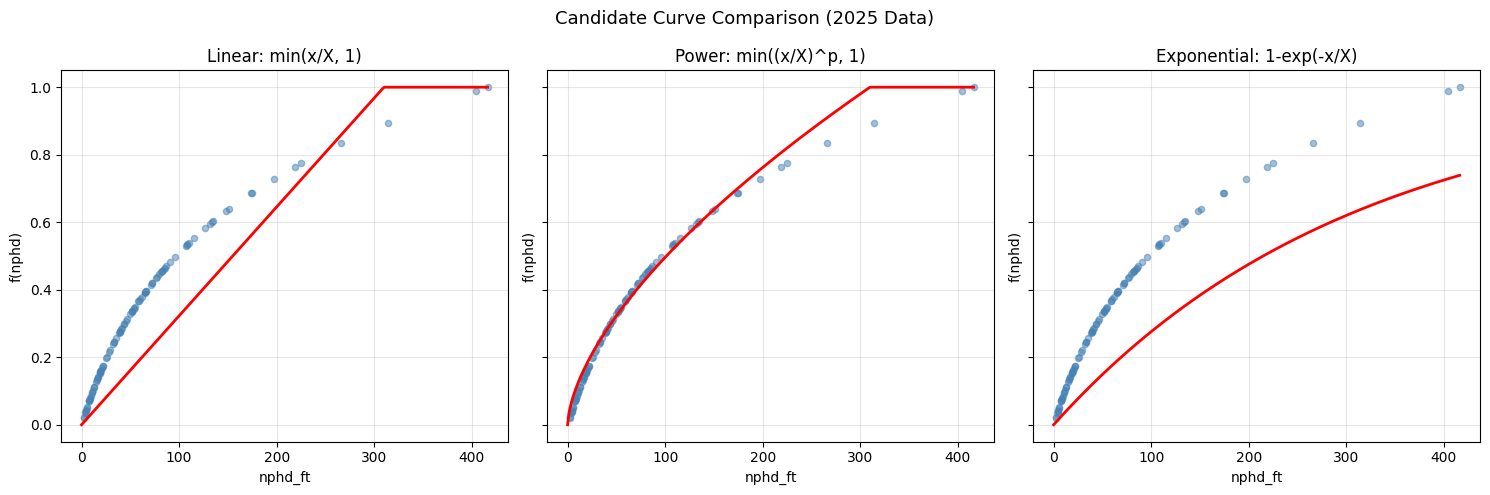

Plot 1 saved.


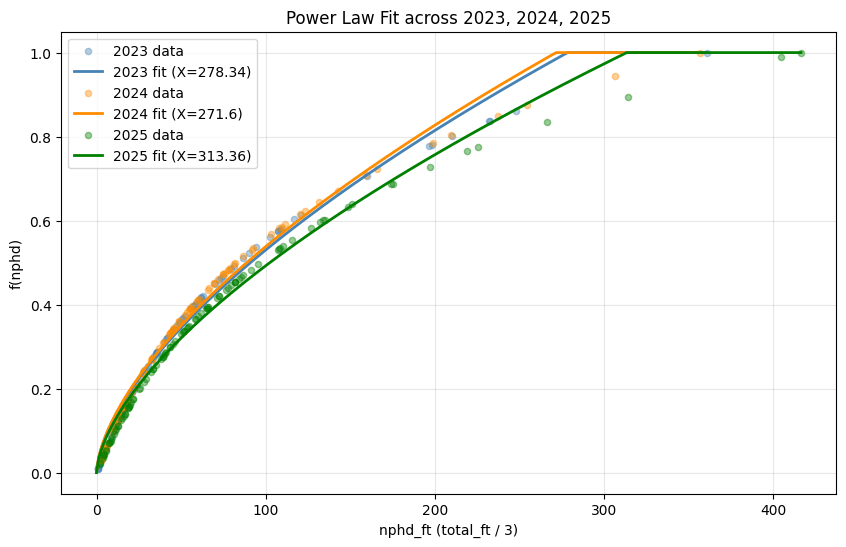

Plot 2 saved.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Plot 1: 3-curve comparison ----
df = pd.read_csv('gphd_2025_working.csv')
df['nphd_ft'] = df['total_ft'] / 3
# f(nphd) column already exists, no need to create it

x = df['nphd_ft'].values
y = df['f(nphd)'].values

X, p = 310, 0.62
x_line = np.linspace(0, x.max(), 300)

f_linear = np.minimum(x_line / X, 1)
f_power  = np.minimum((x_line / X) ** p, 1)
f_exp    = 1 - np.exp(-x_line / X)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
titles = ['Linear: min(x/X, 1)', 'Power: min((x/X)^p, 1)', 'Exponential: 1-exp(-x/X)']
curves = [f_linear, f_power, f_exp]

for ax, title, curve in zip(axes, titles, curves):
    ax.scatter(x, y, alpha=0.5, s=20, color='steelblue')
    ax.plot(x_line, curve, color='red', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('nphd_ft')
    ax.set_ylabel('f(nphd)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Candidate Curve Comparison (2025 Data)', fontsize=13)
plt.tight_layout()
plt.savefig('plot1_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved.")

# ---- Plot 2: Final fit (all 3 years) ----
files  = {'2023': 'gphd_2023_working.csv', '2024': 'gphd_2024_working.csv', '2025': 'gphd_2025_working.csv'}
colors = {'2023': 'steelblue', '2024': 'darkorange', '2025': 'green'}
X_vals = {'2023': 278.34, '2024': 271.60, '2025': 313.36}

plt.figure(figsize=(10, 6))

for year, fname in files.items():
    df_y = pd.read_csv(fname)
    df_y['nphd_ft'] = df_y['total_ft'] / 3

    plt.scatter(df_y['nphd_ft'], df_y['f(nphd)'],
                alpha=0.4, s=20, color=colors[year], label=f'{year} data')

    x_l = np.linspace(0, df_y['nphd_ft'].max(), 300)
    y_l = np.minimum((x_l / X_vals[year]) ** 0.62, 1)
    plt.plot(x_l, y_l, color=colors[year], linewidth=2,
             label=f'{year} fit (X={X_vals[year]})')

plt.xlabel('nphd_ft (total_ft / 3)')
plt.ylabel('f(nphd)')
plt.title('Power Law Fit across 2023, 2024, 2025')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot2_final_fit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved.")